# Packages

In [7]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
from plotly.graph_objs import Figure
from pathlib import Path
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from datetime import datetime, timedelta, date
import math

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

import scipy.stats as stats
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler, LabelEncoder, OrdinalEncoder
import gc
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: "%.4f" % x)
pd.options.plotting.backend = "plotly"

plt.style.use('ggplot')
sns.set_style('darkgrid')

In [8]:
# helper functions
def get_info(df):
    missing_values_train = pd.DataFrame({'Feature': df.columns,
                              'No. of Missing Values': df.isnull().sum().values,
                              '% of Missing Values': ((df.isnull().sum().values)/len(df)*100)})

    unique_values = pd.DataFrame({'Feature': df.columns,
                                'No. of Unique Values': df.nunique().values})

    feature_types = pd.DataFrame({'Feature': df.columns,
                                'DataType': df.dtypes})

    merged_df = pd.merge(missing_values_train, unique_values, on='Feature', how='left')
    merged_df = pd.merge(merged_df, feature_types, on='Feature', how='left')

    return merged_df

def reduce_memory_usage(df: pd.DataFrame, verbose=False) -> pd.DataFrame:
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage before: {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif col_type == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage after: {end_mem:.2f} MB")
        print(f"Reduced by {(start_mem - end_mem) / start_mem * 100:.1f}%")
    
    return df

# Pulling Data

In [9]:
nibrs_path = "./data/nibrs.csv"

data_df = pd.read_csv(nibrs_path)
data_df = reduce_memory_usage(data_df, verbose=True)

/var/folders/8r/qgk4_l1j20gfq28wvs_pxh2r0000gn/T/ipykernel_57779/53905432.py:3: DtypeWarning: Columns (0: arrest_transaction_number, 1: multiple_arrestee_segment_indicator, 2: automatic_weapon_indicator1, 3: automatic_weapon_indicator2, 4: disposition_arrestee_under_18) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(nibrs_path)


Memory usage before: 1477.80 MB
Memory usage after: 1227.65 MB
Reduced by 16.9%


In [10]:
data_df[lambda x: x.ori=="CA0012100"]

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission
176798,6,4,CA0012100,521UQ0G80RVS,2024-12-14,1,24-ACA-00020,2024-12-14,O,N,26A,1,NaN,NaN,NaN,43,M,B,U,U,NaN,2024_207631,0,NaN
176799,6,4,CA0012100,521UQ0GENRVS,2024-12-13,1,24-ACA-00011,2024-12-13,O,N,520,16,NaN,NaN,NaN,45,M,B,N,U,NaN,2024_207632,0,NaN
176800,6,4,CA0012100,521UQ0GEZRVS,2024-12-13,1,24-ACA-00013,2024-12-13,O,N,13A,1,NaN,NaN,NaN,53,M,W,H,N,NaN,2024_207633,0,NaN
176801,6,4,CA0012100,521UQ0GGURVS,2024-12-13,1,24-ACA-00014,2024-12-13,O,N,35B,1,NaN,NaN,NaN,42,M,U,N,R,NaN,2024_207635,0,NaN
176802,6,4,CA0012100,521UQ0G MRVS,2024-12-14,1,24-ACA-00018,2024-12-14,O,N,35A,1,NaN,NaN,NaN,33,F,W,N,U,NaN,2024_207637,0,NaN
176803,6,4,CA0012100,521UQ0GPNRVS,2024-12-14,1,24-ACA-00015,2024-12-14,T,N,13B,1,NaN,NaN,NaN,37,F,B,N,U,NaN,2024_207638,0,NaN
176804,6,4,CA0012100,521UQ0G WRVS,2024-12-14,1,24-ACA-00017,2024-12-14,T,N,35B,1,NaN,NaN,NaN,31,F,B,N,R,NaN,2024_207639,0,NaN
176805,6,4,CA0012100,521UQ0N0URVS,2024-12-13,1,24-ACA-00009,2024-12-13,T,N,35B,1,NaN,NaN,NaN,39,M,W,H,U,NaN,2024_207640,0,NaN
176806,6,4,CA0012100,521UQ0NE4RVS,2024-12-11,1,2412-0818,2024-12-11,O,N,520,1,NaN,NaN,NaN,37,F,B,U,R,NaN,2024_207641,0,NaN
176807,6,4,CA0012100,521UQ0NOHRVS,2024-12-12,1,24-ACA-00005,2024-12-12,O,N,35B,1,NaN,NaN,NaN,24,M,A,N,R,NaN,2024_207642,0,NaN


In [11]:
data_df["ethnicity_of_arrestee"] = data_df["ethnicity_of_arrestee"].fillna("U")
data_df = data_df.assign(
    race_ethnicity_arrestee = lambda x: 
            np.where(
                x.ethnicity_of_arrestee == 'H',
                x.ethnicity_of_arrestee,
                x.race_of_arrestee
            )
)

In [12]:
data_df["incident_date"] = pd.to_datetime(data_df["incident_date"], format="%Y-%m-%d")
data_df["arrest_date"] = pd.to_datetime(data_df["arrest_date"], format="%Y-%m-%d")
data_df["incident_date"] = data_df["incident_date"].fillna(data_df["arrest_date"])

In [13]:
data_df = data_df.assign(
    month= lambda x: x.incident_date.dt.month,
    day= lambda x: x.incident_date.dt.day,
    day_of_week= lambda x: x.incident_date.dt.dayofweek
)

In [14]:
data_df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,month,day,day_of_week
0,6,50,AK0010200,CE0BAA3C728N,2024-08-15,1,55086,2024-12-28,T,N,26A,1,NaN,NaN,NaN,26,M,I,N,R,NaN,2024_1,0,NaN,I,8,15,3
1,6,50,AK0010200,CE0BAAB-728N,2024-08-15,1,54511,2024-08-15,O,N,13B,1,NaN,NaN,NaN,40,M,I,N,N,NaN,2024_2,0,NaN,I,8,15,3
2,6,50,AK0010200,CE0BAAML728N,2024-08-13,1,56308,2025-02-20,T,N,520,1,NaN,NaN,NaN,30,M,I,N,N,NaN,2024_3,0,NaN,I,8,13,1
3,6,50,AK0010200,CE0BAAMM728N,2024-08-13,1,54484,2024-08-13,O,N,13A,1,NaN,NaN,NaN,45,M,W,N,R,NaN,2024_4,0,NaN,W,8,13,1
4,6,50,AK0010200,CE0BAAQC728N,2024-08-09,1,56142,2025-01-12,T,M,26A,1,NaN,NaN,NaN,26,M,A,N,R,NaN,2024_5,0,NaN,A,8,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245962,7,49,WYWHP0000,YX9B5HPU728N,2024-08-24,11,NaN,2024-08-24,O,NaN,90D,1,NaN,NaN,NaN,61,F,W,N,R,NaN,2024_2929863,1,NaN,W,8,24,5
5245963,7,49,WYWHP0000,YX9V5HPU728N,2024-08-21,17,NaN,2024-08-21,T,NaN,90Z,1,NaN,NaN,NaN,73,M,W,N,N,NaN,2024_2929865,1,NaN,W,8,21,2
5245964,7,49,WYWHP0000,Z52SCTD1AEM,2024-12-07,68,NaN,2024-12-07,T,NaN,90D,1,NaN,NaN,NaN,23,M,W,N,N,NaN,2024_2929866,1,NaN,W,12,7,5
5245965,7,49,WYWHP0000,Z5OSCTD1AEM,2024-12-15,60,NaN,2024-12-15,O,NaN,90Z,1,NaN,NaN,NaN,33,M,A,N,N,NaN,2024_2929867,1,NaN,A,12,15,6


In [15]:
data_df_filtered = (
    data_df
        [lambda x: x.incident_date.between(datetime(2024,1,1), datetime(2024,12,31), inclusive="both")]
        .sort_values(by="incident_date")
)

In [16]:
data_df_filtered

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,month,day,day_of_week
3641132,7,12,IL0169400,V-ZL6XAG0W5,2024-01-01,1,NaN,2024-01-01,O,NaN,90D,1,NaN,NaN,NaN,30,F,W,U,NaN,NaN,2024_917558,1,NaN,W,1,1,0
1625879,6,27,NV0020100,O 0GJ4KOZTRX,2024-01-01,1,0,2024-01-01,T,N,13B,1,NaN,NaN,NaN,23,F,B,N,N,NaN,2024_2023726,0,NaN,B,1,1,0
1625878,6,27,NV0020100,O 0GJ4KOZMRS,2024-01-01,1,7108985,2024-01-01,T,C,520,16,NaN,NaN,NaN,33,M,W,H,R,NaN,2024_2023725,0,NaN,H,1,1,0
1625870,6,27,NV0020100,O 0GJ4KOPTRI,2024-01-01,1,8473138,2024-01-01,T,C,13B,1,NaN,NaN,NaN,22,F,W,H,R,NaN,2024_2023715,0,NaN,H,1,1,0
1625869,6,27,NV0020100,O 0GJ4KOPLR1,2024-01-01,1,5020276,2024-01-01,T,N,35A,1,NaN,NaN,NaN,24,F,B,N,R,NaN,2024_2023714,0,NaN,B,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224321,6,21,MI4714700,350MQ523ZL12,2024-12-31,1,240002406617,2024-12-31,T,N,35A,1,NaN,NaN,NaN,40,M,W,U,NaN,NaN,2024_1510502,0,NaN,W,12,31,1
999819,6,15,KS0400100,CE- 0EMU728N,2024-12-31,1,3040A2500001,2024-12-31,O,N,13C,1,NaN,NaN,NaN,27,M,W,N,N,NaN,2024_1212925,0,NaN,W,12,31,1
254747,6,4,CA0194200,V1ZTSZAG0W5,2024-12-31,1,241200021332,2024-12-31,O,C,240,1,NaN,NaN,NaN,40,F,W,U,NaN,NaN,2024_298686,0,NaN,W,12,31,1
180004,6,4,CA0040200,NZ-U7UI4KAEM,2024-12-31,1,24-009455R1,2024-12-31,O,N,13A,1,NaN,NaN,NaN,36,F,W,N,NaN,NaN,2024_211200,0,NaN,W,12,31,1


In [21]:
(
    data_df_filtered
        ["month"]
        .value_counts()
        .sort_index()
        .plot()
)

# Start of Year

In [13]:
num_unique_incident_dates_df = (
    data_df_filtered
        .groupby("ori")
        ["incident_date"]
        .nunique()
        .reset_index()
        .rename(columns={"incident_date" : "incident_date_count"})
        .sort_values(by="incident_date_count")
)
num_unique_incident_dates_df

KeyError: 'Column not found: incident_date'

In [14]:
fig = px.histogram(num_unique_incident_dates_df, x="incident_date_count")
fig.update_traces(marker_line_color="black", marker_line_width=1)
fig.show()

In [15]:
num_unique_incident_dates_df.describe()

,incident_date_count
count,13046.0000
mean,116.9828
std,113.8915
min,1.0000
25%,20.0000
50%,75.0000
75%,194.7500
max,366.0000


In [16]:
(
    data_df_filtered
        .assign(is_jan=lambda x: x.month == 1)
        .groupby("ori")["is_jan"]
        .sum()
        .reset_index(name="row_count")
        .sort_values("row_count")
        .set_index("ori")
        # .tail(20)  # just plot the 20 highest, for legibility
        # .plot(kind='bar')
)

,row_count
ori,
WADI06700,0
NB0830000,0
NB0790600,0
NB0790500,0
NB0730000,0
...,...
TXHPD0000,2676
TXSPD0000,2721
ILCPD0000,2733


In [17]:
(
    data_df_filtered
        .assign(is_jan=lambda x: x.month == 1)
        .groupby("ori")
        .agg(
            row_count=("is_jan", "sum"),
            unique_dates=("incident_date", "nunique")
        )
        .query("unique_dates >= 100")
        .sort_values("row_count")
        .drop(columns="unique_dates")
)


,row_count
ori,
IN0890100,0
CA0390200,0
CA0580000,0
PA0391300,0
IL0163500,0
...,...
TXHPD0000,2676
TXSPD0000,2721
ILCPD0000,2733


In [18]:
zero_jan_reports = (
    data_df_filtered
        .assign(is_jan=lambda x: x.month == 1)
        .groupby("ori")
        .agg(
            row_count=("is_jan", "sum"),
            unique_dates=("incident_date", "nunique")
        )
        .query("unique_dates >= 100")
        .sort_values("row_count")
        .drop(columns="unique_dates")
        .query("row_count == 0")
        .reset_index()
)


In [19]:
zero_jan_reports

,ori,row_count
0,IN0890100,0
1,CA0390200,0
2,CA0580000,0
3,PA0391300,0
4,IL0163500,0
5,PA0390100,0
6,PA0060300,0
7,IN0350000,0
8,PA0360500,0
9,IN0500200,0


### Example ORI: IN0890100

In [20]:
df = data_df_filtered[lambda x: x.ori == 'IN0890100']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,state_name,race_ethnicity_arrestee,month,day,day_of_week
3720590,7,13,IN0890100,2K0HP2ROZ4JW,2024-04-01,1,NaN,2024-04-01,O,NaN,90D,1,NaN,NaN,NaN,67,M,B,N,R,NaN,2024_1021960,1,NaN,Indiana,B,4,1,0
980169,6,13,IN0890100,RU2ZGU7VL71A,2024-04-01,1,240005677701,2024-04-01,O,N,13A,12,NaN,NaN,NaN,36,M,W,N,R,NaN,2024_1188788,0,NaN,Indiana,W,4,1,0
980166,6,13,IN0890100,RU2ZGU7V941A,2024-04-01,1,240005677401,2024-04-01,O,N,35A,1,NaN,NaN,NaN,36,M,W,N,R,NaN,2024_1188785,0,NaN,Indiana,W,4,1,0
3720589,7,13,IN0890100,2K0HP2ROZ2JW,2024-04-02,1,NaN,2024-04-02,O,NaN,90Z,1,NaN,NaN,NaN,27,M,W,N,R,NaN,2024_1021959,1,NaN,Indiana,W,4,2,1
3720588,7,13,IN0890100,2K0HP2RO6YJW,2024-04-02,1,NaN,2024-04-02,O,NaN,90D,1,NaN,NaN,NaN,53,M,W,N,N,NaN,2024_1021958,1,NaN,Indiana,W,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3720670,7,13,IN0890100,2K0HP2ZZZ6JW,2024-12-30,1,NaN,2024-12-30,O,NaN,90Z,1,NaN,NaN,NaN,33,M,W,N,R,NaN,2024_1022054,1,NaN,Indiana,W,12,30,0
3720667,7,13,IN0890100,2K0HP2ZZSXJW,2024-12-30,1,NaN,2024-12-30,O,NaN,90Z,1,NaN,NaN,NaN,48,F,W,N,R,NaN,2024_1022050,1,NaN,Indiana,W,12,30,0
3720672,7,13,IN0890100,2K0HP2ZZZLJW,2024-12-31,1,NaN,2024-12-31,T,NaN,90Z,1,NaN,NaN,NaN,35,M,B,N,R,NaN,2024_1022056,1,NaN,Indiana,B,12,31,1
3720673,7,13,IN0890100,2K0HP2ZZZYJW,2024-12-31,1,NaN,2024-12-31,O,NaN,90C,1,NaN,NaN,NaN,37,M,W,N,R,NaN,2024_1022057,1,NaN,Indiana,W,12,31,1


In [21]:
df.shape

(687, 29)

In [22]:
fig = px.histogram(df, x="incident_date")
fig.update_traces(marker_line_color="black", marker_line_width=1)
fig.show()

### Example ORI: CA0390200
This seems so wrong
https://www.lodi.gov/392/Statistics

In [23]:
df = data_df_filtered[lambda x: x.ori == 'CA0390200']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,state_name,race_ethnicity_arrestee,month,day,day_of_week
385815,6,4,CA0390200,CV2ZGU7NJNBA,2024-08-01,1,240010377701,2024-08-01,O,N,13B,1,NaN,NaN,NaN,58,F,B,N,NaN,NaN,2024_462759,0,NaN,California,B,8,1,3
385813,6,4,CA0390200,CV2ZGU7NJG2A,2024-08-01,1,240010378201,2024-08-01,O,N,280,1,NaN,NaN,NaN,24,M,W,H,NaN,NaN,2024_462757,0,NaN,California,H,8,1,3
385812,6,4,CA0390200,CV2ZGU7NJG0A,2024-08-01,1,240010378101,2024-08-01,O,N,35B,1,NaN,NaN,NaN,41,M,W,N,NaN,NaN,2024_462756,0,NaN,California,W,8,1,3
385798,6,4,CA0390200,CV2ZGU7N6XJA,2024-08-01,1,240010422301,2024-09-15,T,N,290,1,NaN,NaN,NaN,58,M,W,N,NaN,NaN,2024_462742,0,NaN,California,W,8,1,3
3227514,7,4,CA0390200,2K0HQUHOZXJW,2024-08-01,1,NaN,2024-08-01,O,NaN,90C,1,NaN,NaN,NaN,55,F,W,N,R,NaN,2024_385084,1,NaN,California,W,8,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3227481,7,4,CA0390200,2K0HQU82SCJW,2024-12-30,1,NaN,2024-12-30,O,NaN,90Z,1,NaN,NaN,NaN,27,M,W,H,U,NaN,2024_385051,1,NaN,California,H,12,30,0
3227484,7,4,CA0390200,2K0HQU82Z7JW,2024-12-30,1,NaN,2024-12-30,T,NaN,90Z,1,NaN,NaN,NaN,27,M,W,U,N,NaN,2024_385054,1,NaN,California,W,12,30,0
385990,6,4,CA0390200,CV2ZGU7ULG A,2024-12-31,2,240010508002,2024-12-31,O,N,290,1,NaN,NaN,NaN,31,F,U,U,NaN,NaN,2024_462960,0,NaN,California,U,12,31,1
3227485,7,4,CA0390200,2K0HQU82ZYJW,2024-12-31,1,NaN,2024-12-31,O,NaN,90D,1,NaN,NaN,NaN,31,M,W,H,N,NaN,2024_385055,1,NaN,California,H,12,31,1


In [24]:
df.shape

(699, 29)

In [25]:
fig = px.histogram(df, x="incident_date")
fig.update_traces(marker_line_color="black", marker_line_width=1)
fig.show()

### Graphing for all 34 ORIs

In [25]:
to_graph_oris = zero_jan_reports["ori"].to_list()

In [26]:
import io
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import plotly.express as px

output_path = "all_jan_incident_histograms.pdf"

with PdfPages(output_path) as pdf:
    for ori in to_graph_oris:
        df = data_df_filtered.loc[lambda x: x.ori == ori]

        fig = px.histogram(
            df,
            x="incident_date",
            title=f"Incident Date Distribution — ORI: {ori} - Len: {len(df)}"
        )
        fig.update_traces(marker_line_color="black", marker_line_width=1)

        # Convert Plotly figure to PNG in memory
        img_bytes = fig.to_image(format="png", scale=2)

        # Load image into matplotlib
        img = plt.imread(io.BytesIO(img_bytes))

        # Create a clean PDF page
        plt.figure(figsize=(11, 8.5))  # landscape layout
        plt.imshow(img)
        plt.axis("off")

        # Extra label at top (redundant but ensures clarity)
        plt.suptitle(f"ORI: {ori}", fontsize=16, y=0.98)

        pdf.savefig()
        plt.close()

print(f"Saved to {output_path}")


Saved to all_jan_incident_histograms.pdf


### Example ORI: CA0194200
Los Angeles Police Department

In [26]:
df = data_df_filtered[lambda x: x.ori == 'CA0194200']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,state_name,race_ethnicity_arrestee,month,day,day_of_week
245058,6,4,CA0194200,CE0BRV5-728N,2024-03-07,1,240300000107,2024-03-07,O,N,23C,1,NaN,NaN,NaN,30,M,B,U,NaN,NaN,2024_288620,0,NaN,California,B,3,7,3
245059,6,4,CA0194200,CE0BRV5M728N,2024-03-07,1,240300000103,2024-03-07,O,C,35A,1,NaN,NaN,NaN,51,M,W,U,NaN,NaN,2024_288621,0,NaN,California,W,3,7,3
245062,6,4,CA0194200,CE0BRVRD728N,2024-03-07,1,240300000112,2024-03-07,O,N,23C,1,NaN,NaN,NaN,33,M,B,U,NaN,NaN,2024_288625,0,NaN,California,B,3,7,3
245061,6,4,CA0194200,CE0BRVR9728N,2024-03-07,1,240300000110,2024-03-07,O,N,23C,1,NaN,NaN,NaN,40,M,B,U,NaN,NaN,2024_288624,0,NaN,California,B,3,7,3
245060,6,4,CA0194200,CE0BRVQ9728N,2024-03-07,1,240300000109,2024-03-07,O,N,23C,1,NaN,NaN,NaN,31,F,W,U,NaN,NaN,2024_288623,0,NaN,California,W,3,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254769,6,4,CA0194200,V1ZTZI6G0W5,2024-12-31,1,241200021366,2024-12-31,O,N,13A,1,NaN,NaN,NaN,54,F,A,U,NaN,NaN,2024_298714,0,NaN,California,A,12,31,1
254768,6,4,CA0194200,V1ZTZ-FG0W5,2024-12-31,1,241200021361,2024-12-31,O,N,35A,1,NaN,NaN,NaN,37,M,B,U,NaN,NaN,2024_298713,0,NaN,California,B,12,31,1
254746,6,4,CA0194200,V1ZTSXYG0W5,2024-12-31,1,241200021324,2024-12-31,O,N,13B,1,NaN,NaN,NaN,62,M,B,U,NaN,NaN,2024_298684,0,NaN,California,B,12,31,1
254744,6,4,CA0194200,V1ZTSX G0W5,2024-12-31,1,241200021323,2024-12-31,O,N,13A,1,NaN,NaN,NaN,33,M,B,U,NaN,NaN,2024_298682,0,NaN,California,B,12,31,1


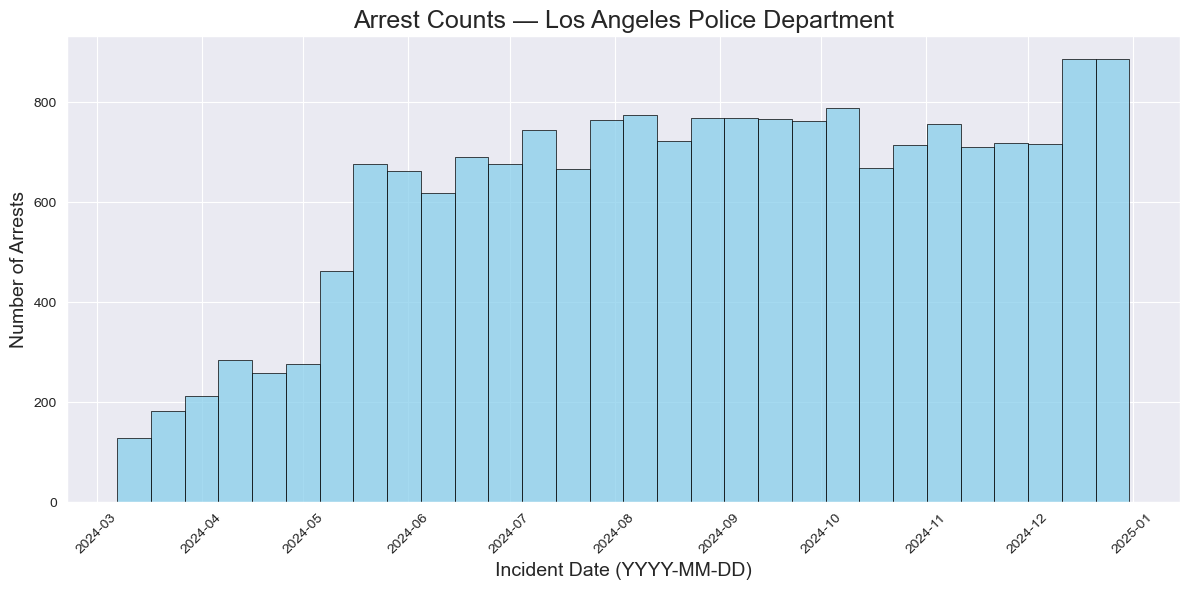

In [31]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=df,
    x="incident_date",
    bins=30,
    kde=False,
    color="skyblue",
    edgecolor="black"
)
ax.set_title("Arrest Counts — Los Angeles Police Department", fontsize=18)
ax.set_xlabel("Incident Date (YYYY-MM-DD)", fontsize=14)
ax.set_ylabel("Number of Arrests", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Look at poisson process vs uniform

# Empty for Each Month

In [24]:
zero_month_reports_list = []

for i in range(1, 13):
    temp = (
        data_df_filtered
            .assign(is_specific_month=lambda x: x.month == i)
            .groupby("ori")
            .agg(
                row_count=("is_specific_month", "sum"),
                unique_dates=("incident_date", "nunique")
            )
            .query("unique_dates >= 100")
            .sort_values("row_count")
            .drop(columns="unique_dates")
            .query("row_count == 0")
            .reset_index()
    )
    zero_month_reports_list.append(temp)

zero_month_reports = pd.concat(zero_month_reports_list).drop_duplicates()
for t in zero_jan_reports:
    del t
gc.collect()


48229

In [25]:
zero_month_reports.reset_index(drop=True, inplace=True)
zero_month_reports.shape

(219, 2)

In [26]:
to_graph_oris = zero_month_reports["ori"].to_list()

In [54]:
output_path = "all_incident_histograms.pdf"

with PdfPages(output_path) as pdf:
    for ori in to_graph_oris:
        df = data_df_filtered.loc[lambda x: x.ori == ori]

        fig = px.histogram(
            df,
            x="incident_date",
            title=f"Incident Date Distribution — ORI: {ori} - Len: {len(df)}"
        )
        fig.update_traces(marker_line_color="black", marker_line_width=1)

        # Convert Plotly figure to PNG in memory
        img_bytes = fig.to_image(format="png", scale=2)

        # Load image into matplotlib
        img = plt.imread(io.BytesIO(img_bytes))

        # Create a clean PDF page
        plt.figure(figsize=(11, 8.5))  # landscape layout
        plt.imshow(img)
        plt.axis("off")

        # Extra label at top (redundant but ensures clarity)
        plt.suptitle(f"ORI: {ori}", fontsize=16, y=0.98)

        pdf.savefig()
        plt.close()

print(f"Saved to {output_path}")

Saved to all_incident_histograms.pdf


In [33]:
zero_month_reports["ori"]

0      IN0890100
1      CA0390200
2      CA0580000
3      PA0391300
4      IL0163500
5      PA0390100
6      PA0060300
7      IN0350000
8      PA0360500
9      IN0500200
10     UT0185200
11     AL0390000
12     AL0390100
13     OR0030600
14     TX0840100
15     CA0194200
16     GA0650000
17     NY0515500
18     FL0501700
19     CA0151000
20     FL0560000
21     FL0560100
22     FL0560200
23     NJ0122500
24     NY0146700
25     NY0145100
26     PA0220400
27     CA0196500
28     IL0169X00
29     NJ0091000
30     WADI06800
31     TX1460100
32     CA0489965
33     IL0490000
34     NH0050000
35     MS0440000
36     NY0060100
37     MS0180200
38     IN0660000
39     NJ0130300
40     MA0144500
41     WA0311900
42     IN0330200
43     WI0120100
44     MTDI00000
45     IL0491300
46     GA1590100
47     MI6160400
48     MA0050300
49     IN0750000
50     WI0490200
51     MI6116100
52     FL0060300
53     MI2312300
54     MI6160300
55     MS0530000
56     MTDI06200
57     MI6162500
58     GA15400

In [34]:
zero_month_reports = (
    zero_month_reports
        .assign(
            total_incidents=lambda x: x.ori.map(
                data_df["ori"].value_counts()
            ).fillna(0).astype(int)
        )
        .sort_values(by="total_incidents")
)
zero_month_reports

,ori,row_count,total_incidents
187,IL0221600,0,119
43,WI0120100,0,124
55,MS0530000,0,129
143,OH0840200,0,132
147,UT0120000,0,138
123,GA1390000,0,140
156,GA0760300,0,140
204,NC0880100,0,144
14,TX0840100,0,144
214,MO0550100,0,145


Wait expired, Browser is being closed by watchdog.


# General Algorithm for Underreporting

for each ORI, look for any org where one of the monthly totals is 50% less than sum(total)/12

In [27]:
oris_to_investigate = []

for ori, group in data_df.groupby("ori"):
    total_incidents = len(group)
    if total_incidents == 0:
        continue
    expected_avg = total_incidents / 12

    month_counts = group["month"].value_counts().reindex(range(1, 13), fill_value=0)
    for month, count in month_counts.items():
        if count < (expected_avg * 0.5):
            oris_to_investigate.append({
                "ori": ori,
                "month": month,
                "month_count": count,
                "expected_monthly": expected_avg,
                "total": total_incidents
            })
            break

underreported_oris = pd.DataFrame(oris_to_investigate)
underreported_oris

,ori,month,month_count,expected_monthly,total
0,AK0010400,4,0,6.4167,77
1,AK0010500,12,5,12.4167,149
2,AK0010600,12,9,28.5000,342
3,AK0010700,9,1,3.7500,45
4,AK0010800,1,1,4.7500,57
...,...,...,...,...,...
8667,WY0220000,3,1,3.3333,40
8668,WY0220100,12,3,6.2500,75
8669,WY0230000,1,0,0.7500,9
8670,WY0230200,1,0,0.0833,1


In [28]:
underreported_oris["ori"].nunique()

8672

In [38]:
(~zero_month_reports["ori"].isin(underreported_oris["ori"])).any()

np.False_

In [39]:
underreported_oris[~underreported_oris["ori"].isin(zero_month_reports["ori"])]

,ori,month,month_count,expected_monthly,total
0,AK0010400,4,0,6.4167,77
1,AK0010500,12,5,12.4167,149
2,AK0010600,12,9,28.5000,342
3,AK0010700,9,1,3.7500,45
4,AK0010800,1,1,4.7500,57
...,...,...,...,...,...
8666,WY0210000,10,1,5.3333,64
8667,WY0220000,3,1,3.3333,40
8668,WY0220100,12,3,6.2500,75
8669,WY0230000,1,0,0.7500,9


In [40]:
data_df_filtered["ori"].nunique()

13046

In [41]:
underreported_oris[~underreported_oris["ori"].isin(zero_month_reports["ori"])].sample(5, random_state=42)

,ori,month,month_count,expected_monthly,total
5157,NM0130200,12,75,171.8333,2062
5600,OH0540500,1,0,0.6667,8
637,CA0301100,1,0,6.2500,75
3498,MN0181000,3,1,2.5000,30
7359,TX1560000,1,0,0.2500,3


## Looking at Examples

In [20]:
def ori_graphing(to_look_ori, small=True):
    fig = px.histogram(data_df_filtered[lambda x: x.ori == to_look_ori], x="incident_date")
    fig.update_traces(marker_line_color="black", marker_line_width=1)
    fig.show()
    if small:
        fig = px.scatter(
            data_df_filtered[data_df_filtered["ori"] == f"{to_look_ori}"],
            x="incident_date",
            y=[1] * len(data_df_filtered[data_df_filtered["ori"] == f"{to_look_ori}"]),
            title=f"Incident Dates for ORI {to_look_ori}",
            color_discrete_sequence=["steelblue"]
        )

        fig.show()
    else:
        filtered_df = data_df_filtered[data_df_filtered["ori"] == f"{to_look_ori}"]
        fig = px.box(
            filtered_df,
            x="incident_date",
            y=None,  # y is not needed for a vertical boxplot, so None for a univariate box along incident_date
            points="all",  # Show all points (like a swarm/strip plot)
            title=f"Incident Dates for ORI {to_look_ori}",
            color_discrete_sequence=["steelblue"]
        )
        fig.update_traces(marker_line_color="black", marker_line_width=1)
        fig.update_layout(yaxis_title=None, xaxis_title="Incident Date")
        fig.show()

### CA0010100

In [31]:
ori_graphing("CA0010100")

### AK0010400
KETCHIKAN PD 

some small alaskan city; maybe this one makes sense 

In [43]:
fig = px.histogram(data_df_filtered[lambda x: x.ori == 'AK0010400'], x="incident_date")
fig.update_traces(marker_line_color="black", marker_line_width=1)
fig.show()

In [44]:
to_look_ori = "AK0010400"
fig = px.scatter(
    data_df_filtered[data_df_filtered["ori"] == f"{to_look_ori}"],
    x="incident_date",
    y=[1] * len(data_df_filtered[data_df_filtered["ori"] == f"{to_look_ori}"]),
    title=f"Incident Dates for ORI {to_look_ori}",
    color_discrete_sequence=["steelblue"]
)

fig.show()

### NM0130200
Hobbs Police Department

largeish city in NM

In [45]:
ori_graphing("NM0130200", small=False)

### OH0540500
fort recovery police department

it has 3 employees it seems in a "village" of 1,474

In [46]:
ori_graphing("OH0540500")

### CA0301100

Laguna Beach Police Department

23k population

In [47]:
ori_graphing("CA0301100")

In [48]:
data_df_filtered[lambda x: x.ori == "CA0301100"].shape

(75, 29)

https://www.latimes.com/socal/daily-pilot/news/story/2023-03-30/drugs-alcohol-top-reasons-for-arrests-in-laguna-beach-police-say

article says laguna beach made 1.1k arrests in 2023

## Adding Size Filter

In [49]:
oris_to_investigate = []

for ori, group in data_df.groupby("ori"):
    total_incidents = len(group)
    if total_incidents < 24:
        continue
    expected_avg = total_incidents / 12

    month_counts = group["month"].value_counts().reindex(range(1, 13), fill_value=0)
    for month, count in month_counts.items():
        if count < (expected_avg * 0.5):
            oris_to_investigate.append({
                "ori": ori,
                "month": month,
                "month_count": count,
                "expected_monthly": expected_avg,
                "total": total_incidents
            })
            break

underreported_oris = pd.DataFrame(oris_to_investigate)
underreported_oris

,ori,month,month_count,expected_monthly,total
0,AK0010400,4,0,6.4167,77
1,AK0010500,12,5,12.4167,149
2,AK0010600,12,9,28.5000,342
3,AK0010700,9,1,3.7500,45
4,AK0010800,1,1,4.7500,57
...,...,...,...,...,...
5300,WY0200100,4,11,28.4167,341
5301,WY0210000,10,1,5.3333,64
5302,WY0220000,3,1,3.3333,40
5303,WY0220100,12,3,6.2500,75


In [50]:
(~zero_month_reports["ori"].isin(underreported_oris["ori"])).any()

np.False_

In [51]:
underreported_oris[~underreported_oris["ori"].isin(zero_month_reports["ori"])].sample(5, random_state=42)

,ori,month,month_count,expected_monthly,total
2408,MO0230100,1,1,2.1667,26
2715,NB0780100,5,3,6.4167,77
3164,NJ0140500,4,1,2.8333,34
2234,MN0020300,6,2,4.4167,53
3581,OK0050000,3,0,3.0833,37


### MO0230100

Kahoka, MO 
2k pop

In [52]:
ori_graphing("MO0230100")

### NB0780100
Wahoo Police Department
4k pop

In [53]:
ori_graphing("NB0780100")

# Total Data Set

In [10]:
data_path = "./data/final_dataset.csv"

final_df = pd.read_csv(data_path)
final_df = reduce_memory_usage(final_df, verbose=True)

Memory usage before: 26.96 MB
Memory usage after: 15.28 MB
Reduced by 43.3%


In [12]:
final_df.head()

,ori,subject_race,month,agency_name,state,geoid_county,geoid_place,geo_type,place_name,total_pop,median_hh_income,housing_units,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,total_arrests,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown,force_total
0,CA0010100,asian,1,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,2,0,0,0,0,0,0,0,0,2,0,0,0,2
1,CA0010100,asian,2,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,4,0,0,0,0,0,0,0,0,0,0,0,0,0
2,CA0010100,asian,3,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,8,0,0,0,0,0,0,0,0,0,0,0,0,0
3,CA0010100,asian,4,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,4,0,0,0,0,0,0,0,0,0,0,0,0,0
4,CA0010100,asian,5,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,2,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
(
    final_df
        .groupby(["ori", "month"])
        .agg({
            "total_arrests" : "sum",
            "force_total" : "sum"
        })
        .reset_index()
)

,ori,month,total_arrests,force_total
0,CA0010100,1,59,11
1,CA0010100,2,54,2
2,CA0010100,3,88,5
3,CA0010100,4,54,2
4,CA0010100,5,69,4
...,...,...,...,...
9451,OHCLP0000,8,286,22
9452,OHCLP0000,9,270,17
9453,OHCLP0000,10,290,28
9454,OHCLP0000,11,264,22


In [17]:
(
    final_df
        .groupby(["ori", "month"])
        .agg({
            "total_arrests" : "sum",
            "force_total" : "sum"
        })
        .reset_index()
        [lambda x: x.total_arrests == 0]
        ["ori"]
        .nunique()
)

131

In [18]:
(
    final_df
        .groupby(["ori", "month"])
        .agg({
            "total_arrests" : "sum",
            "force_total" : "sum"
        })
        .reset_index()
        [lambda x: x.total_arrests == 0]
        ["ori"]
        .unique()
)

<ArrowStringArray>
['CA0060200', 'CA0071300', 'CA0071600', 'CA0151000', 'CA0194200', 'CA0196500',
 'CA0196600', 'CA0270100', 'CA0270200', 'CA0270500',
 ...
 'OH0521200', 'OH0572200', 'OH0580100', 'OH0650800', 'OH0730100', 'OH0760600',
 'OH0761000', 'OH0770700', 'OH0772700', 'OH0850100']
Length: 131, dtype: str

In [29]:
(
    final_df
        .groupby(["ori", "month"])
        .agg({
            "total_arrests" : "sum",
            "force_total" : "sum"
        })
        .reset_index()
        [lambda x: x.ori == "OH0772700"]
        .set_index("month")
        [["total_arrests", "force_total"]]
        .plot(kind="bar")
)